### This script contains the following:

#### 1. Importing libraries and datasets
#### 2. Dendrograms with reduced dataset


### 1. Importing libraries and datasets

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
# Defining a path for importing/exporting
path = r'/Users/peterguan/ClimateWins ML'

In [5]:
# Importing the PLEASANT WEATHER dataset
pleasantweather = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [6]:
# Checking if the dataset imported successfully 
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
# Checking the dimensions of the dataset
pleasantweather.shape

(22950, 16)

In [8]:
# Importing the REDUCED dataset
climatewins_reduced = pd.read_csv(os.path.join(path, 'climatewins_PCA.csv'), index_col = 0)

In [9]:
# Checking if the dataset imported successfully
climatewins_reduced.head()

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9
0,-13.168638,-4.093840,-1.020229,-0.464229,-3.466228,-1.816399,1.393487,-3.636568,0.859451
1,-13.316832,-3.962197,-0.251053,-0.964536,-3.048192,-1.579995,0.938122,-2.501133,0.583141
2,-13.391043,-3.198842,0.123470,-0.819537,-2.392621,-0.739999,-0.102578,-2.549790,0.334700
3,-12.502780,-6.070120,-1.701847,0.555061,-0.566340,0.159194,0.249860,-0.484396,0.236056
4,-12.124600,-4.892509,-2.754221,-2.054976,-0.927253,2.110454,-1.435280,-1.436609,-1.302909


In [10]:
# Checking the dimensions of the dataset
climatewins_reduced.shape

(365, 9)

### 2. Dendrograms with reduced dataset

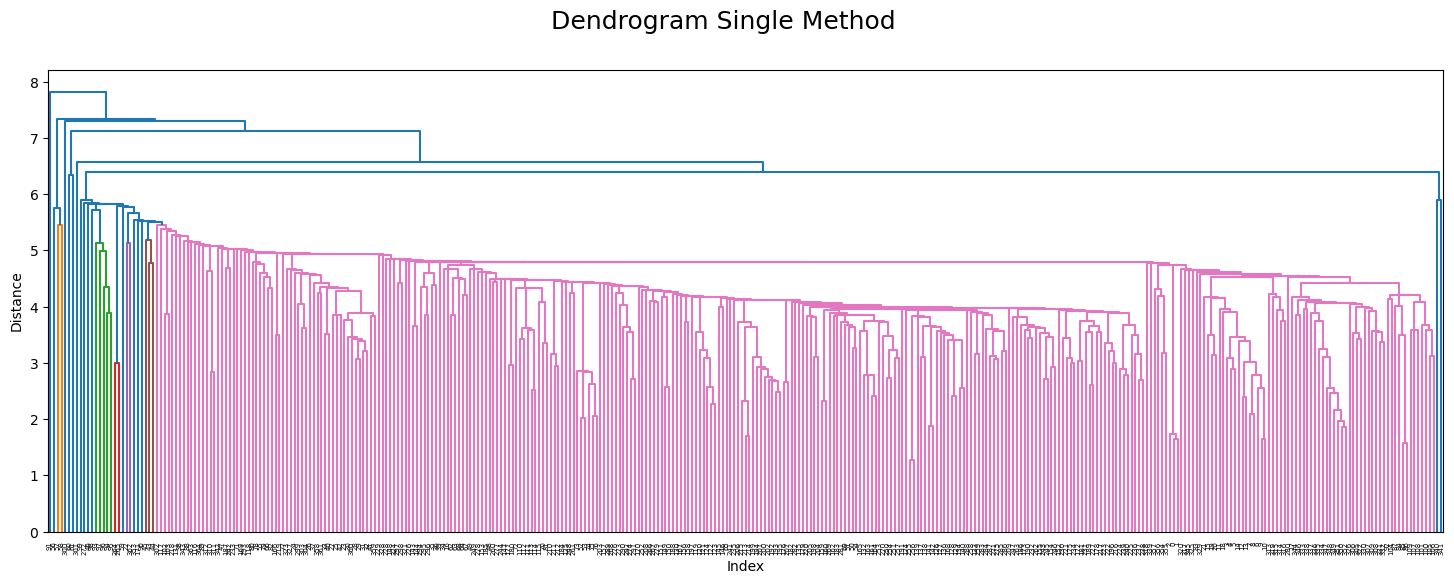

In [12]:
# Dendrogram (SINGLE METHOD)
distance_single = linkage(climatewins_reduced.loc[:,
['PCA1',
'PCA2',
'PCA3',
'PCA4',
'PCA5',
'PCA6',
'PCA7',
'PCA8',
'PCA9',]],method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

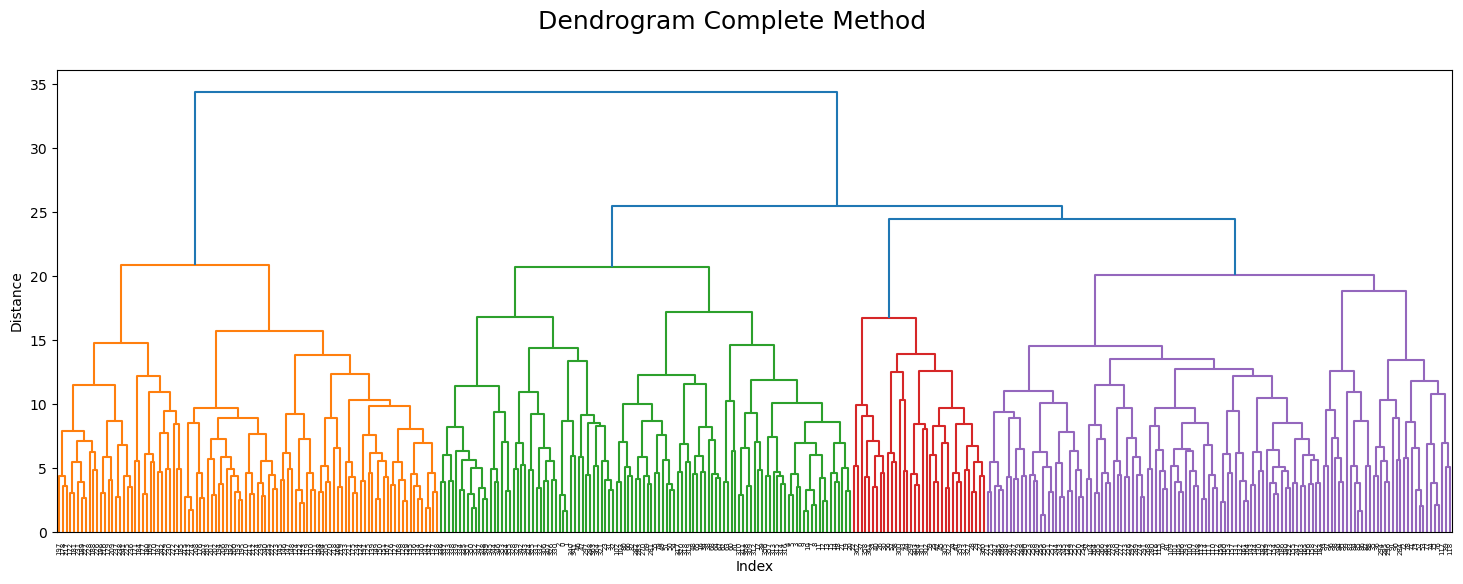

In [13]:
# Dendrogram (COMPLETE METHOD)
distance_single = linkage(climatewins_reduced.loc[:,
['PCA1',
'PCA2',
'PCA3',
'PCA4',
'PCA5',
'PCA6',
'PCA7',
'PCA8',
'PCA9',]],method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method",fontsize=18)
plt.show()

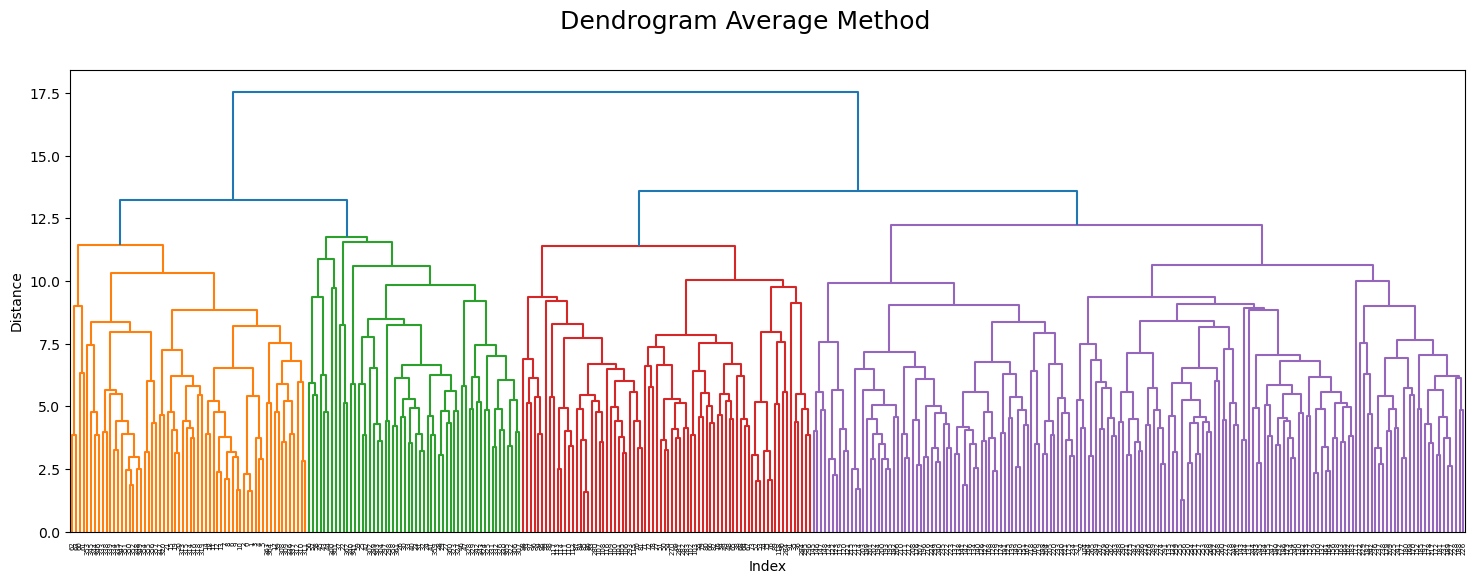

In [14]:
# Dendrogram (AVERAGE METHOD)
distance_single = linkage(climatewins_reduced.loc[:,
['PCA1',
'PCA2',
'PCA3',
'PCA4',
'PCA5',
'PCA6',
'PCA7',
'PCA8',
'PCA9',]],method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method",fontsize=18)
plt.show()

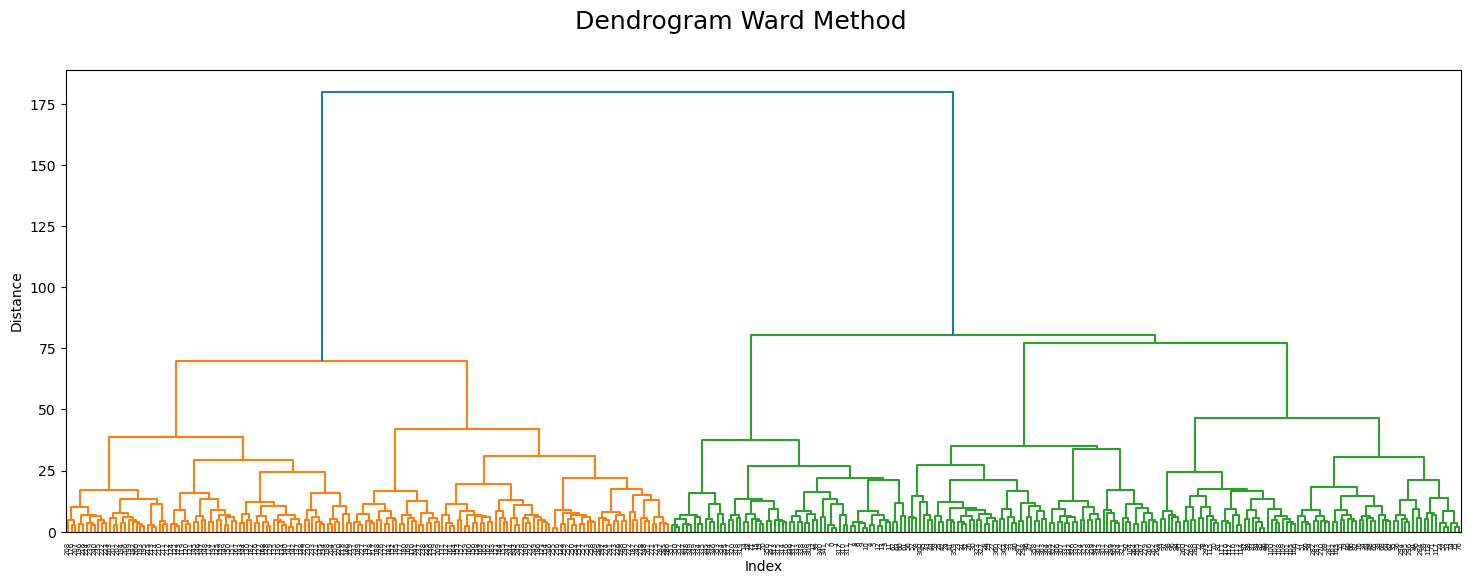

In [15]:
# Dendrogram (WARD METHOD)
distance_single = linkage(climatewins_reduced.loc[:,
['PCA1',
'PCA2',
'PCA3',
'PCA4',
'PCA5',
'PCA6',
'PCA7',
'PCA8',
'PCA9',]],method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method",fontsize=18)
plt.show()

<Axes: title={'center': 'K = 3'}, xlabel='PCA1', ylabel='PCA2'>

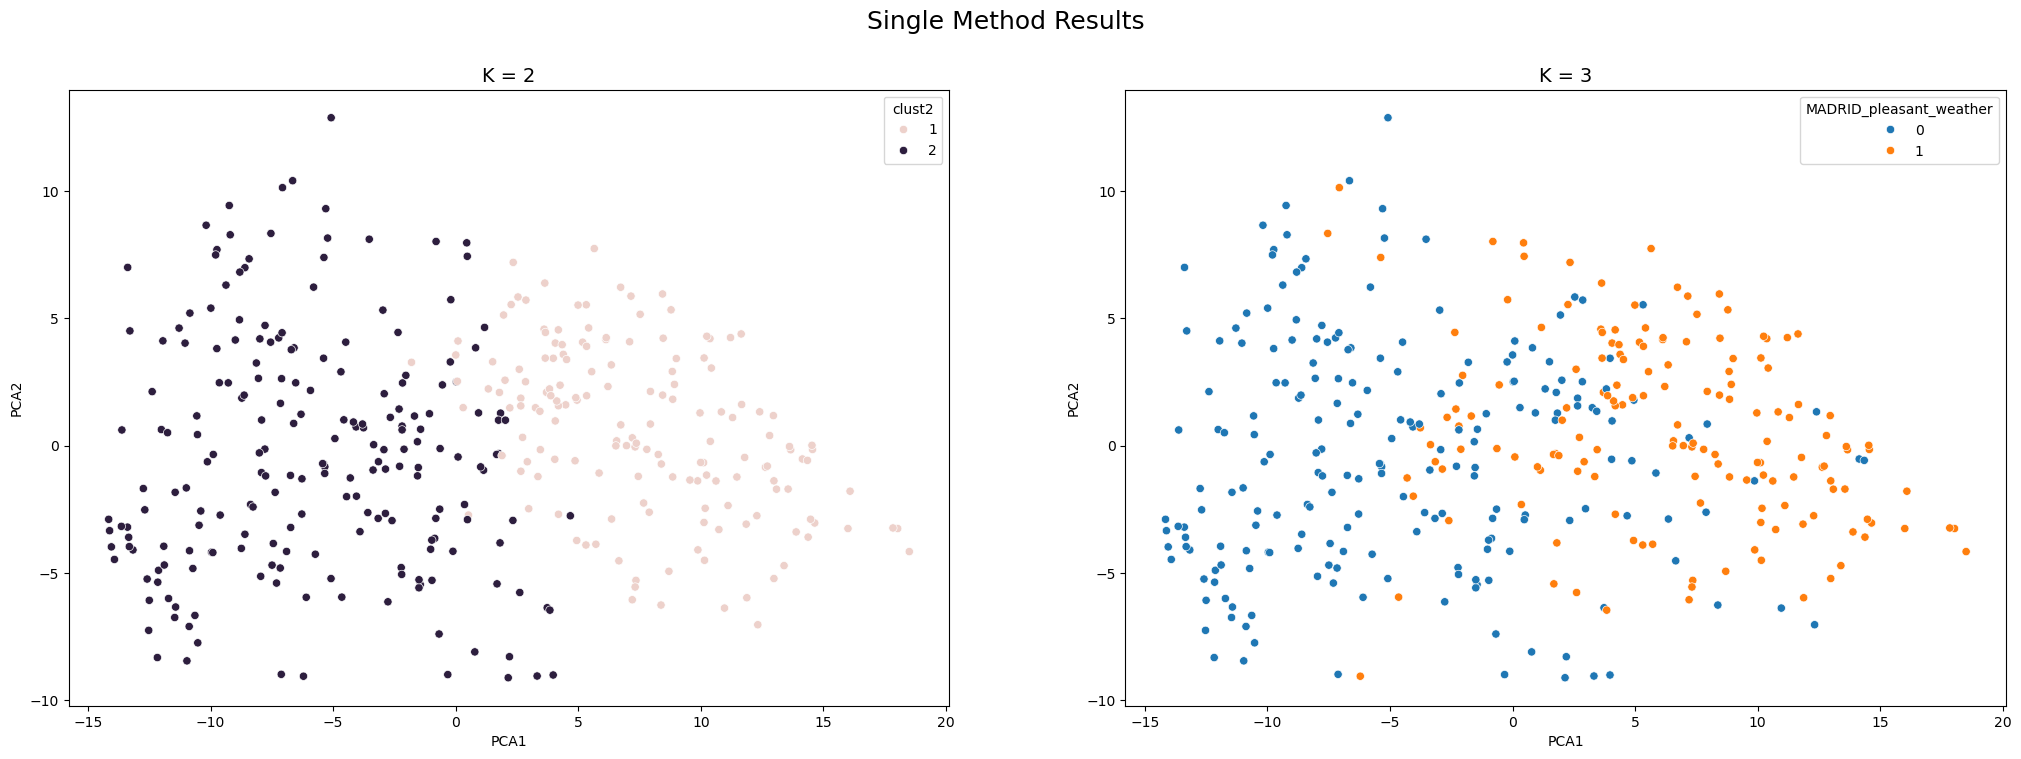

In [37]:
# Creating 2 CLUSTERS with the PCA dataset (USING PCA1 and PCA2)
climatewins_reduced_copy=climatewins_reduced.copy()

climatewins_reduced_copy['clust2']=fcluster(distance_single,2, criterion='maxclust')
climatewins_reduced_copy.head()

# Plotting the clusters against the answers
plt.figure(figsize=(25,8))

plt.suptitle("Single Method Results",fontsize=18)

plt.subplot(1,2,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="PCA1",y="PCA2", data=climatewins_reduced_copy, hue="clust2")

plt.subplot(1,2,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="PCA1",y="PCA2", data=climatewins_reduced_copy, hue=pleasantweather['MADRID_pleasant_weather'])

